In [65]:
import json
import os
import re

# Read Jsonl files and see how many have "is_proven" as True
def read_jsonl(file_path):
    with open(file_path, 'r') as f:
        for line in f:
            yield json.loads(line)

def load_jsonl(file_path):
    data = []
    for item in read_jsonl(file_path):
        data.append(item)
    filename = os.path.basename(file_path)
    return filename, data

def count_proven(data):
    count = 0
    for item in data:
        if item.get("is_proven", True):
            count += 1
    return count

def count_compiled(data):
    count = 0
    for item in data:
        if item.get("compiles", True):
            count += 1
    return count

def count_proof_lines(content):
    # Look for the first pattern
    # :=

    # -- <some comment> --

    # by
    regex = r":=\s*?--[\s|\S]*?by"
    # Find the first match
    match = re.search(regex, content)
    if match:
        # Get the start and end positions of the match
        start, end = match.span()
        # Extract just the remaining content
        substring = content[end:]
        # Remove all empty lines
        lines = substring.splitlines()
        lines = [line for line in lines if line.strip()]
        # Count the number of lines
        return len(lines)
    else:
        return 0

def count_induction_proofs(proofs):
    count = 0
    for proof in proofs:
        if "induction" in proof.lower():
            count += 1
    return count

In [66]:
def count_attempts(log_file_path, attempt_marker_text):
    with open(log_file_path, 'r') as f:
        content = f.read()
    # Look for the pattern "(Try #\d+) {attempt_marker_text}"
    regex = rf"\(Try #\d+\) {re.escape(attempt_marker_text)}"
    # Find all matches
    matches = re.findall(regex, content)
    return len(matches)

import enum
class TaskType(enum.Enum):
    SPEC = "spec"
    IMPL = "impl"
    UNION = "union"

class ProofMode(enum.Enum):
    FS = "few_shot"
    COPRA = "copra"

def get_strategy_name(dataset_name: str) -> tuple[TaskType, ProofMode, str]:
    is_spec_generation = "spec" in dataset_name
    is_impl = "impl" in dataset_name
    is_copra = "copra" in dataset_name
    is_few_shot = "few_shot" in dataset_name and not is_copra
    # After "proof_"
    if "proof_" not in dataset_name:
        model_name = "o4"
    else:
        model_name = dataset_name.split("proof_")[-1]
    if "." in model_name:
        model_name = model_name.split(".")[0]
    if is_spec_generation:
        if is_few_shot:
            return (TaskType.SPEC, ProofMode.FS, model_name)
        elif is_copra:
            return (TaskType.SPEC, ProofMode.COPRA, model_name)
        else:
            raise ValueError(f"Unknown proof mode in dataset name: {dataset_name}")
    elif is_impl:
        if is_few_shot:
            return (TaskType.IMPL, ProofMode.FS, model_name)
        elif is_copra:
            return (TaskType.IMPL, ProofMode.COPRA, model_name)
        else:
            raise ValueError(f"Unknown proof mode in dataset name: {dataset_name}")
    else:
        raise ValueError(f"Unknown task type in dataset name: {dataset_name}")

In [67]:
data_paths = [
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_few_shot_proof.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof/2025-05-09_17-05-24/test_report/2025-05-09_17-05-25"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_few_shot_proof.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof/2025-05-11_05-18-54/test_report/2025-05-11_05-18-55"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_few_shot_proof_o4_mini.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_o4_mini/2025-05-14_03-16-19/test_report/2025-05-14_03-16-21"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_few_shot_proof_o4_mini.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_o4_mini/2025-05-13_18-07-23/test_report/2025-05-13_18-07-25"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_few_shot_proof_claude_3_7.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_claude_3_7/2025-05-14_06-53-46/test_report/2025-05-14_06-53-48"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_few_shot_proof_claude_3_7.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_claude_3_7/2025-05-13_23-35-36/test_report/2025-05-13_23-35-37"
    ),
    (   "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_copra_proof.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_copra_proof/2025-05-13_01-31-57/test_report/2025-05-13_01-31-59"
    ),
    (   "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_copra_proof.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_copra_proof/2025-05-15_06-17-49/test_report/2025-05-15_06-17-50"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_copra_proof_claude_3_7.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_copra_proof_claude_3_7/2025-05-14_18-41-28/test_report/2025-05-14_18-41-30"
    ),
    ( 
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_copra_proof_claude_3_7.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_copra_proof_claude_3_7/2025-05-14_11-06-10/test_report/2025-05-14_11-06-11"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_spec_few_shot_proof_deepseek_r1.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_deepseek_r1/2025-05-16_01-15-40/test_report/2025-05-16_01-15-42"
    ),
    (
        "/home/amthakur/Project/clever-prover/.logs/checkpoints/few_shot_impl_few_shot_proof_deepseek_r1.jsonl",
        "/home/amthakur/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_deepseek_r1/2025-05-15_11-00-46/test_report/2025-05-15_11-00-48"
    )
]

for i in range(len(data_paths)):
    # replace <user_name> with actual user name
    data_paths[i] = (data_paths[i][0].replace("<user_name>", os.getenv("USER")), data_paths[i][1].replace("<user_name>", os.getenv("USER")))

induction_proofs = []
approach_proved_maps = {}
approach_compiled_spec_maps = {}
approach_compiled_impl_maps = {}
for data_path, proofs_path in data_paths:
    print("--" * 20)
    dataset_name, data = load_jsonl(data_path)
    task_t, proof_mode, model_name = get_strategy_name(dataset_name)
    print(f"Approach: {task_t}, {proof_mode}, {model_name}")
    print(f"Dataset: {dataset_name}")
    print(f"Number of items: {len(data)}")
    print(f"{count_proven(data) / len(data) * 100:.3f}% of items are proven")
    print(f"{count_compiled(data) / len(data) * 100:.3f}% of items are compiled")
    print(f"Number of proven items: {count_proven(data)}")
    print(f"Number of compiled items: {count_compiled(data)}")
    proved_ids = [d["problem_id"] for d in data if d.get("is_proven", True)]
    approach_proved_maps[(task_t, proof_mode, model_name)] = proved_ids
    average_proof_time = [d["proof_time"] for d in data if d.get("is_proven", True)]
    average_generation_time = [d["generation_time"] for d in data if d.get("compiles", True)]
    if task_t == TaskType.SPEC:
        approach_compiled_spec_maps[(proof_mode, model_name)] = [d["problem_id"] for d in data if d.get("compiles", True)]
    else:
        approach_compiled_impl_maps[(proof_mode, model_name)] = [d["problem_id"] for d in data if d.get("compiles", True)]
    print(f"Average proof time: {sum(average_proof_time) / len(average_proof_time) if average_proof_time else 0}")
    print(f"Average generation time: {sum(average_generation_time) / len(average_generation_time) if average_generation_time else 0}")
    # Read all proofs generated
    proofs = {}
    num_induction_proofs = 0
    for proof_file in os.listdir(proofs_path):
        with open(os.path.join(proofs_path, proof_file), 'r') as f:
            problem_id = proof_file.split("_")[-1][:-len(".lean")]
            try:
                problem_id = int(problem_id)
            except Exception:
                print(f"Problem ID: {proof_file} is not an integer")
                raise
            content = f.read()
            if "sorry" in content and problem_id in proved_ids:
                print(f"Problem ID: {problem_id}, Sorry found")
                continue
            # Count the number of lines in the proof
            proof_lines = count_proof_lines(content)
            if problem_id in proved_ids:
                num_induction_proofs += 1
                induction_proofs.append((problem_id, dataset_name, proof_lines, content))
            if problem_id in proved_ids:
                proofs[problem_id] = proof_lines
    # Print the number of lines in each proof
    for problem_id, proof_lines in proofs.items():
        print(f"Problem ID: {problem_id}, Proof lines: {proof_lines}")
    print(f"Number of induction proofs: {num_induction_proofs}")
    # Print the average number of lines in the proofs
    average_proof_lines = sum(proofs.values()) / len(proofs) if proofs else 0
    print(f"Average proof lines: {average_proof_lines}")
    max_proof_lines = max(proofs.values()) if proofs else 0
    print(f"Max proof lines: {max_proof_lines}")
    min_proof_lines = min(proofs.values()) if proofs else 0
    print(f"Min proof lines: {min_proof_lines}")
# Print all induction proofs
for problem_id, dataset_name, proof_lines, content in induction_proofs:
    print()
    print()
    print(f"-- Problem ID: {problem_id}, Dataset: {dataset_name}, Proof lines: {proof_lines}")
    # Print the proof
    print(content)
    print("--" * 20)

----------------------------------------
Approach: TaskType.SPEC, ProofMode.FS, o4
Dataset: few_shot_spec_few_shot_proof.jsonl
Number of items: 160
0.625% of items are proven
85.000% of items are compiled
Number of proven items: 1
Number of compiled items: 136
Average proof time: 124.26517987251282
Average generation time: 68.38005905291614
Problem ID: 42, Proof lines: 16
Number of induction proofs: 1
Average proof lines: 16.0
Max proof lines: 16
Min proof lines: 16
----------------------------------------
Approach: TaskType.IMPL, ProofMode.FS, o4
Dataset: few_shot_impl_few_shot_proof.jsonl
Number of items: 160
0.625% of items are proven
68.750% of items are compiled
Number of proven items: 1
Number of compiled items: 110
Average proof time: 291.63309359550476
Average generation time: 51.351814111796294
Problem ID: 41, Proof lines: 6
Number of induction proofs: 1
Average proof lines: 6.0
Max proof lines: 6
Min proof lines: 6
----------------------------------------
Approach: TaskType.S

In [68]:
log_paths = [
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_o4_mini",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_o4_mini",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_claude_3_7",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_claude_3_7",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_copra_proof",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_copra_proof",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_copra_proof_claude_3_7",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_copra_proof_claude_3_7",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_spec_few_shot_proof_deepseek_r1",
    "/home/<user_name>/Project/clever-prover/.logs/eval_few_shot_impl_few_shot_proof_deepseek_r1"
]
for (task_t, proof_mode, model_name), proved_ids in approach_proved_maps.items():
    print("--" * 20)
    print(f"Approach: {task_t}, {proof_mode}, {model_name}")
    print(f"Number of proved problems: {len(proved_ids)}")
    print(f"Proved problem IDs: {proved_ids}")

----------------------------------------
Approach: TaskType.SPEC, ProofMode.FS, o4
Number of proved problems: 1
Proved problem IDs: [42]
----------------------------------------
Approach: TaskType.IMPL, ProofMode.FS, o4
Number of proved problems: 1
Proved problem IDs: [41]
----------------------------------------
Approach: TaskType.SPEC, ProofMode.FS, o4_mini
Number of proved problems: 2
Proved problem IDs: [53, 76]
----------------------------------------
Approach: TaskType.IMPL, ProofMode.FS, o4_mini
Number of proved problems: 3
Proved problem IDs: [41, 53, 85]
----------------------------------------
Approach: TaskType.SPEC, ProofMode.FS, claude_3_7
Number of proved problems: 1
Proved problem IDs: [53]
----------------------------------------
Approach: TaskType.IMPL, ProofMode.FS, claude_3_7
Number of proved problems: 3
Proved problem IDs: [41, 139, 53]
----------------------------------------
Approach: TaskType.SPEC, ProofMode.COPRA, o4
Number of proved problems: 3
Proved problem I

In [69]:
model_based_results = {}
# list all eval_*.log files in the above directories
for i in range(len(log_paths)):
    # replace <user_name> with actual user name
    log_paths[i] = log_paths[i].replace("<user_name>", os.getenv("USER") or "not_set")

prob_count = 160
for log_path in log_paths:
    # Take the last part of the path and remove `eval_` to get the dataset name
    dataset_name = log_path.split("/")[-1].replace("eval_", "")
    # print(f"dataset_name: {dataset_name}")
    # print(f"path: {log_path}")
    task, proof_mode, model_name = get_strategy_name(dataset_name)
    # list all timestamped log files in the directory
    log_file_name_nums = []
    problem_to_attempts = {}
    model_based_results[task] = model_based_results.get(task, {})
    model_based_results[task][proof_mode] = model_based_results[task].get(proof_mode, {})
    model_based_results[task][proof_mode][model_name] = model_based_results[task][proof_mode].get(model_name, problem_to_attempts)
    if not os.path.exists(log_path):
        print(f"Log path {log_path} does not exist")
        continue
    dir_files = [f for f in os.listdir(log_path) if os.path.isdir(os.path.join(log_path, f))]
    # Sort the directories in reverse chronological order
    dir_files = sorted(dir_files, reverse=True)
    for f in dir_files:
        l_path = os.path.join(log_path, f)            
        log_files = [f for f in os.listdir(l_path) if f.startswith("eval_") and f.endswith(".log")]
        # each log files should be `eval_*_\d+.log`
        # Get the \d+ part and sort the files based on that
        # print(f"Checking log files in {l_path}, count: {len(log_files)}")
        for log_file in log_files:
            match = re.search(r"eval_.*_(\d+)\.log", log_file)
            if match:
                prob_id = int(match.group(1))
                if prob_id not in problem_to_attempts:
                    count_iso = count_attempts(os.path.join(l_path, log_file), "Generating isomorphism")
                    count_impl = count_attempts(os.path.join(l_path, log_file), "Generating implementation")
                    count_proof = count_attempts(os.path.join(l_path, log_file), "Generating proof")
                    log_file_name_nums.append((log_file, prob_id))
                    compiled_maps = approach_compiled_spec_maps if task == TaskType.SPEC else approach_compiled_impl_maps
                    # Check if the problem id is in the compiled maps for this dataset
                    compiled_map = compiled_maps.get((proof_mode, model_name), [])
                    # Check if the problem id is in the proved ids for this dataset
                    if prob_id in approach_proved_maps.get((task, proof_mode, model_name), []):
                        # If it is, we can use it
                        problem_to_attempts[prob_id] = {"iso": count_iso, "impl": count_impl, "proof": count_proof, "proved": True, "compiled": prob_id in compiled_map}
                    else:
                        problem_to_attempts[prob_id] = {"iso": count_iso, "impl": count_impl, "proof": count_proof, "proved": False, "compiled": prob_id in compiled_map}
        log_file_name_nums = sorted(log_file_name_nums, key=lambda x: x[1])
        if len(log_file_name_nums) == prob_count:
            break
    # print(f"Log files in {log_path}:")
    # print(f"Problem count: {len(log_file_name_nums)}")
    # print("=" * 40)
    # print(f"Processing log path: {log_path}")
    # print("=" * 40)
    # Sort the problem_to_attempts by problem id
    # problem_to_attempts = dict(sorted(problem_to_attempts.items()))
    # for prob_id, attempts in problem_to_attempts.items():
    #     print(f"Problem ID: {prob_id}, Generating isomorphism attempts: {attempts['iso']}, Generating implementation attempts: {attempts['impl']}, Generating proof attempts: {attempts['proof']}, Proved: {attempts['proved']}, Compiled: {attempts['compiled']}")
    # print()
    # print('--' * 20)

model_aggregate_results = {}
aggregates_compiled_spec = {}
aggregates_compiled_impl = {}
for task, proof_mode_map in model_based_results.items():
    for proof_mode, model_map in proof_mode_map.items():
        for model_name, problem_to_attempts in model_map.items():
            model_aggregate_results[task] = model_aggregate_results.get(task, {})
            proof_mode_name = proof_mode # "CoPRA-based Generation" if proof_mode == ProofMode.COPRA else "Few-shot Generation"
            model_aggregate_results[task][proof_mode_name] = model_aggregate_results[task].get(proof_mode_name, {})
            model_aggregate_results[task][proof_mode_name][model_name] = model_aggregate_results[task][proof_mode_name].get(model_name, {})
            results = model_aggregate_results[task][proof_mode_name][model_name]
            compiled_spec = results.get("compiled_spec", [])
            compiled_impl = results.get("compiled_impl", [])
            proved = results.get("proved", [])
            results["compiled_spec"] = compiled_spec
            results["compiled_impl"] = compiled_impl
            results["proved"] = proved
            proved_ids = approach_proved_maps.get((task, proof_mode, model_name), [])
            # Bucketize the compiled and proved counts based on the # of attempts taken to compile or prove
            max_iso_count = max((v["iso"] for v in problem_to_attempts.values()), default=0)
            max_impl_count = max((v["impl"] for v in problem_to_attempts.values()), default=0)
            max_proof_count = max((v["proof"] for v in problem_to_attempts.values()), default=0)
            min_impl_count = min((v["impl"] for v in problem_to_attempts.values()), default=0)
            min_iso_count = min((v["iso"] for v in problem_to_attempts.values()), default=0)
            min_proof_count = min((v["proof"] for v in problem_to_attempts.values()), default=0)
            # Create buckets for compiled and proved counts
            compiled_iso_buckets = [0] * (max_iso_count + 1) 
            compiled_impl_buckets = [0] * (max_impl_count + 1)
            proved_buckets = [0] * (max_proof_count + 1)
            increasing_compiled_iso_counts_order = sorted(problem_to_attempts.values(), key=lambda x: x["iso"])
            increasing_compiled_impl_counts_order = sorted(problem_to_attempts.values(), key=lambda x: x["impl"])
            increasing_proved_counts_order = sorted(problem_to_attempts.values(), key=lambda x: x["proof"])
            for v in increasing_compiled_iso_counts_order:
                if v["compiled"]:
                    compiled_iso_buckets[v["iso"]] += 1
            for v in increasing_compiled_impl_counts_order:
                if v["compiled"]:
                    compiled_impl_buckets[v["impl"]] += 1
            for v in increasing_proved_counts_order:
                if v["proved"]:
                    proved_buckets[v["proof"]] += 1
            proved_buckets[0] = 0 # No proofs can be generated with 0 attempts
            # Convert to cumulative counts
            for i in range(1, len(compiled_iso_buckets)):
                compiled_iso_buckets[i] += compiled_iso_buckets[i - 1]
            for i in range(1, len(compiled_impl_buckets)):
                compiled_impl_buckets[i] += compiled_impl_buckets[i - 1]
            for i in range(1, len(proved_buckets)):
                proved_buckets[i] += proved_buckets[i - 1]
            compiled_spec.extend(compiled_iso_buckets)
            compiled_impl.extend(compiled_impl_buckets)
            proved.extend(proved_buckets)
            if max_iso_count > 0:
                iso_so_far = aggregates_compiled_spec.get(model_name, [])
                old_len = len(iso_so_far)
                if len(iso_so_far) < len(compiled_iso_buckets):
                    iso_so_far.extend([0] * (len(compiled_iso_buckets) - len(iso_so_far)))
                for i in range(len(compiled_iso_buckets)):
                    if i < old_len:
                        iso_so_far[i] = iso_so_far[i] + compiled_iso_buckets[i]
                    else:
                        if i > 0:
                            assert compiled_iso_buckets[i] - compiled_iso_buckets[i - 1] >= 0, f"Negative value encountered for {task}, {proof_mode}, {model_name} at bucket {i}: {compiled_iso_buckets}"
                            iso_so_far[i] += iso_so_far[i - 1] + compiled_iso_buckets[i] - compiled_iso_buckets[i - 1]
                        else:
                            iso_so_far[i] += compiled_iso_buckets[i]
                aggregates_compiled_spec[model_name] = iso_so_far
            if max_impl_count > 0:
                impl_so_far = aggregates_compiled_impl.get(model_name, [])
                old_len = len(impl_so_far)
                if len(impl_so_far) < len(compiled_impl_buckets):
                    impl_so_far.extend([0] * (len(compiled_impl_buckets) - len(impl_so_far)))
                for i in range(len(compiled_impl_buckets)):
                    if i < old_len:
                        impl_so_far[i] = impl_so_far[i] + compiled_impl_buckets[i]
                    else:
                        if i > 0:
                            assert compiled_impl_buckets[i] - compiled_impl_buckets[i - 1] >= 0, f"Negative value encountered for {task}, {proof_mode}, {model_name} at bucket {i}: {compiled_impl_buckets}"
                            impl_so_far[i] += impl_so_far[i - 1] + compiled_impl_buckets[i] - compiled_impl_buckets[i - 1]
                        else:
                            impl_so_far[i] += compiled_impl_buckets[i]
                aggregates_compiled_impl[model_name] = impl_so_far
            # print("--" * 20)
            # print(f"Aggregated results for {task}, {proof_mode}, {model_name}:")
            # print(f"Maximum attempts for isomorphism generation: {max_iso_count}")
            # print(f"Maximum attempts for implementation generation: {max_impl_count}")
            # print(f"Maximum attempts for proof generation: {max_proof_count}")
            # print(f"Minimum attempts for isomorphism generation: {min_iso_count}")
            # print(f"Minimum attempts for implementation generation: {min_impl_count}")
            # print(f"Minimum attempts for proof generation: {min_proof_count}")
            # print(f"Compiled (isomorphism) buckets: {compiled_iso_buckets}")
            # print(f"Compiled (implementation) buckets: {compiled_impl_buckets}")
            # print(f"Proved buckets: {proved_buckets}")
            # if len(model_aggregate_results[task]) == 2:
            #     if proof_mode_name in model_aggregate_results[TaskType.SPEC] and proof_mode_name in model_aggregate_results[TaskType.IMPL]:
            #         if model_name in model_aggregate_results[TaskType.SPEC][proof_mode_name] and model_name in model_aggregate_results[TaskType.IMPL][proof_mode_name]:
            #             spec_proved = model_aggregate_results[TaskType.SPEC][proof_mode_name][model_name]["proved"]
            #             impl_proved = model_aggregate_results[TaskType.IMPL][proof_mode_name][model_name]["proved"]
            #             union_proved = list(set(spec_proved) & set(impl_proved))
            #             print(f"Union proved for {task}, {proof_mode}, {model_name}: {union_proved}")

            # print(f"Proved IDs for {task}, {proof_mode}, {model_name}: {proved_ids}, count: {len(proved_ids)}")
            # print(f"Task: {task}, Proof mode: {proof_mode}, Model: {model_name}")
            # total_proved = sum(1 for v in problem_to_attempts.values() if v["proved"])
            # total_compiled = sum(1 for v in problem_to_attempts.values() if v["compiled"])
            # total_iso_attempts = sum(v["iso"] for v in problem_to_attempts.values())
            # total_impl_attempts = sum(v["impl"] for v in problem_to_attempts.values())
            # total_proof_attempts = sum(v["proof"] for v in problem_to_attempts.values())
            # avg_iso_attempts = total_iso_attempts / len(problem_to_attempts) if problem_to_attempts else 0
            # avg_impl_attempts = total_impl_attempts / len(problem_to_attempts) if problem_to_attempts else 0
            # avg_proof_attempts = total_proof_attempts / len(problem_to_attempts) if problem_to_attempts else 0
            # print(f"Total problems: {len(problem_to_attempts)}")
            # print(f"Total proved: {total_proved}, Success rate: {total_proved / len(problem_to_attempts) * 100 if problem_to_attempts else 0:.3f}%")
            # print(f"Total compiled: {total_compiled}, Success rate: {total_compiled / len(problem_to_attempts) * 100 if problem_to_attempts else 0:.3f}%")
            # print(f"Average isomorphism generation attempts: {avg_iso_attempts:.3f}")
            # print(f"Average implementation generation attempts: {avg_impl_attempts:.3f}")
            # print(f"Average proof generation attempts: {avg_proof_attempts:.3f}")
            # print("--" * 20)

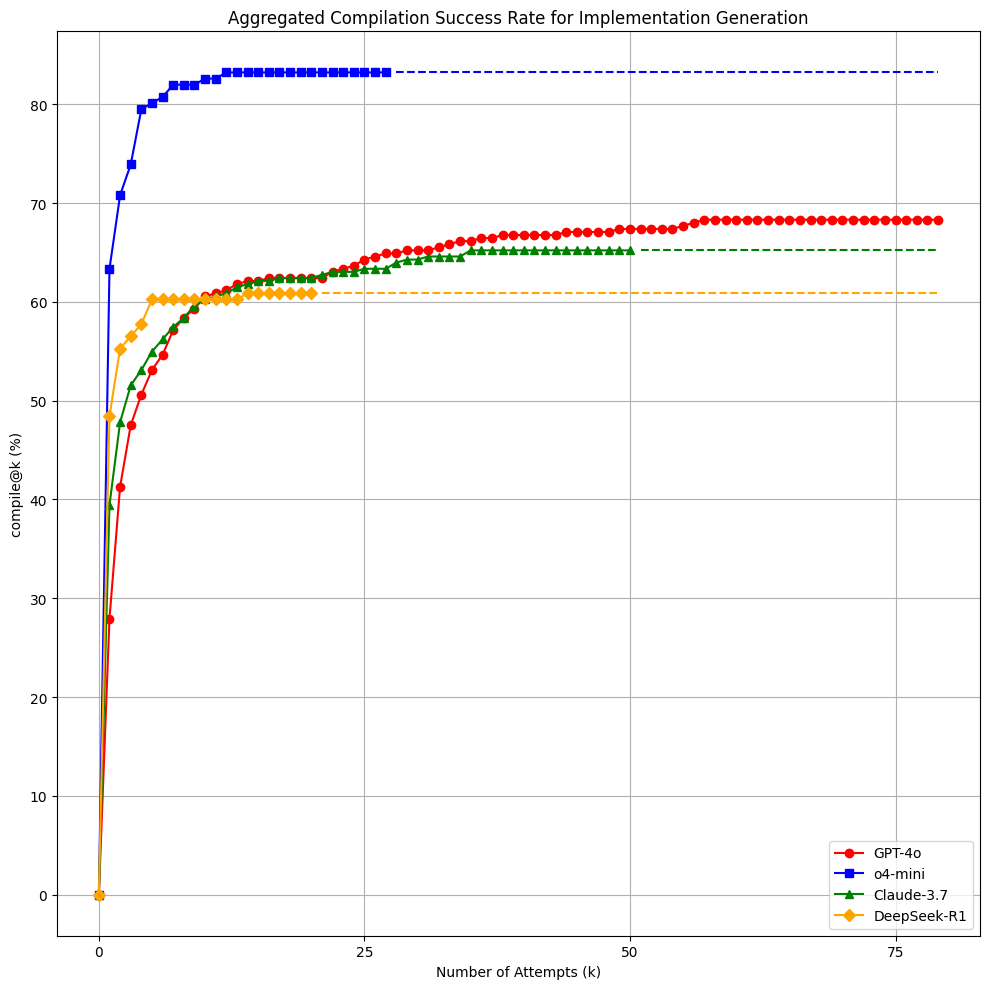

In [70]:
# Plot the aggregated results using matplotlib
import matplotlib.pyplot as plt

def get_pretty_model_name(name: str) -> str:
    name_map = {
        "o4": "GPT-4o",
        "o4_mini": "o4-mini",
        "claude_3_7": "Claude-3.7",
        "deepseek_r1": "DeepSeek-R1"
    }
    return name_map.get(name, name)

def get_prob_count(model_name: str) -> int:
    count_map = {
        "o4": (prob_count + 1) * 2,
        "o4_mini": (prob_count + 1),
        "claude_3_7": (prob_count + 1) * 2,
        "deepseek_r1": (prob_count + 1)
    }
    return count_map.get(model_name, prob_count)

plt.figure(figsize=(10, 10))
plt.xlabel('Number of Attempts (k)')
plt.ylabel('compile@k (%)')
plt.title('Aggregated Compilation Success Rate for Implementation Generation')
plt.xticks(range(0, max([len(tmp) for tmp in aggregates_compiled_impl.values()]), 25))
plt.yticks(range(0, 101, 10))
max_tries = max([len(tmp) for tmp in aggregates_compiled_impl.values()])
marker_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
marker_shapes = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'H', '+']
for i, model_name in enumerate(aggregates_compiled_impl):
    impl_so_far = aggregates_compiled_impl[model_name]
    plt.plot(range(len(impl_so_far)), 
        [v / get_prob_count(model_name) * 100 for v in impl_so_far], 
        label=get_pretty_model_name(model_name), 
        marker=marker_shapes[i % len(marker_shapes)], 
        color=marker_colors[i % len(marker_colors)])
    if len(impl_so_far) < max_tries:
        # extend the line to max_tries with a dashed line
        plt.plot(range(len(impl_so_far), max_tries), 
            [impl_so_far[-1] / get_prob_count(model_name) * 100] * (max_tries - len(impl_so_far)), 
            linestyle='--', color=marker_colors[i % len(marker_colors)])
    # Add the % percentage text at the end of each line
    # plt.text(max_tries - 1, impl_so_far[-1] / get_prob_count(model_name) * 100, f"{impl_so_far[-1] / get_prob_count(model_name) * 100:.1f}%", 
    #     color=marker_colors[i % len(marker_colors)], fontsize=8, verticalalignment='bottom')
    plt.grid(True)
# Plot the legend on the bottom right
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('aggregated_compilation_success_impl.png')
plt.show()

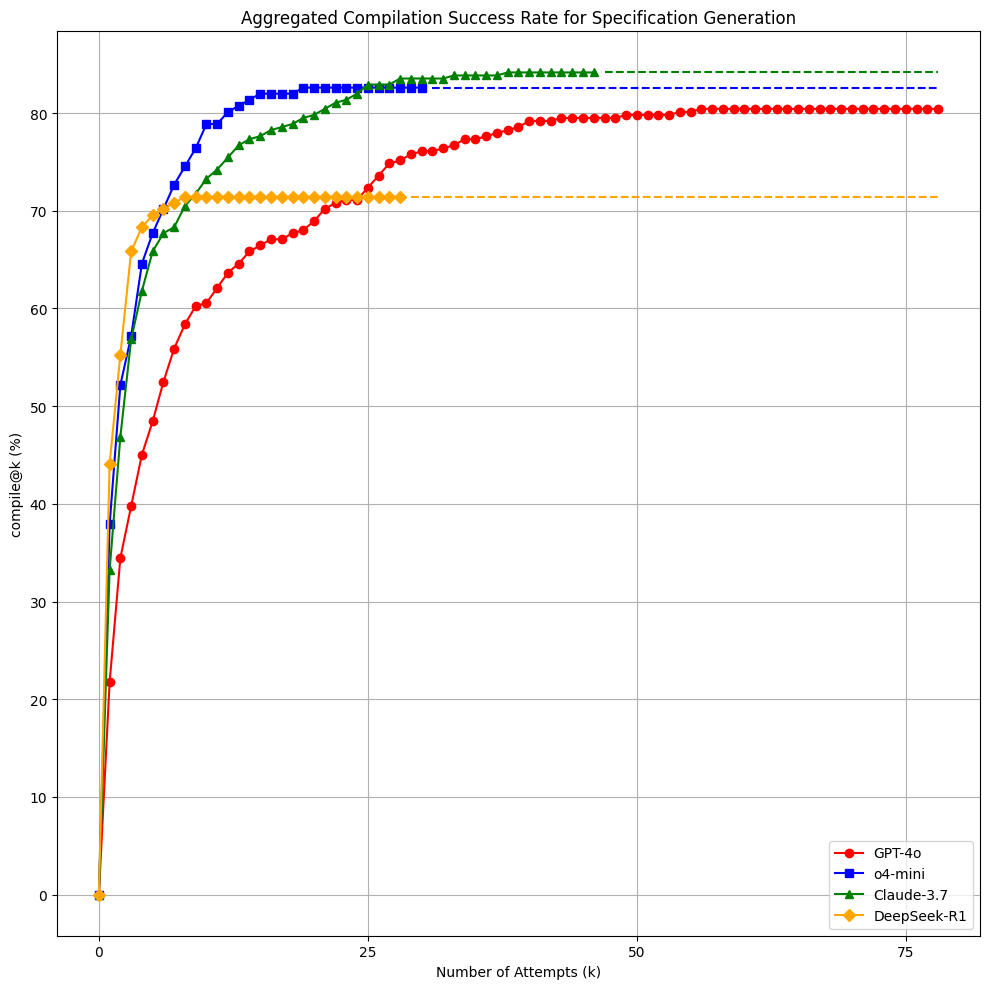

In [71]:
plt.figure(figsize=(10, 10))
plt.xlabel('Number of Attempts (k)')
plt.ylabel('compile@k (%)')
plt.title('Aggregated Compilation Success Rate for Specification Generation')
plt.xticks(range(0, max([len(tmp) for tmp in aggregates_compiled_spec.values()]), 25))
plt.yticks(range(0, 101, 10))
max_tries = max([len(tmp) for tmp in aggregates_compiled_spec.values()])
for i, model_name in enumerate(aggregates_compiled_spec):
    iso_so_far = aggregates_compiled_spec[model_name]
    plt.plot(range(len(iso_so_far)), 
        [v / get_prob_count(model_name) * 100 for v in iso_so_far], 
        label=get_pretty_model_name(model_name), 
        marker=marker_shapes[i % len(marker_shapes)], 
        color=marker_colors[i % len(marker_colors)])
    if len(iso_so_far) < max_tries:
        # extend the line to max_tries with a dashed line
        plt.plot(range(len(iso_so_far), max_tries), 
            [iso_so_far[-1] / get_prob_count(model_name) * 100] * (max_tries - len(iso_so_far)), 
            linestyle='--', color=marker_colors[i % len(marker_colors)])
    # Add the % percentage text at the end of each line
    # plt.text(max_tries - 1, iso_so_far[-1] / get_prob_count(model_name) * 100, f"{iso_so_far[-1] / get_prob_count(model_name) * 100:.1f}%", 
    #     color=marker_colors[i % len(marker_colors)], fontsize=8, verticalalignment='bottom')
    plt.grid(True)
# Plot the legend on the bottom right
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('aggregated_compilation_success_spec.png')
plt.show()

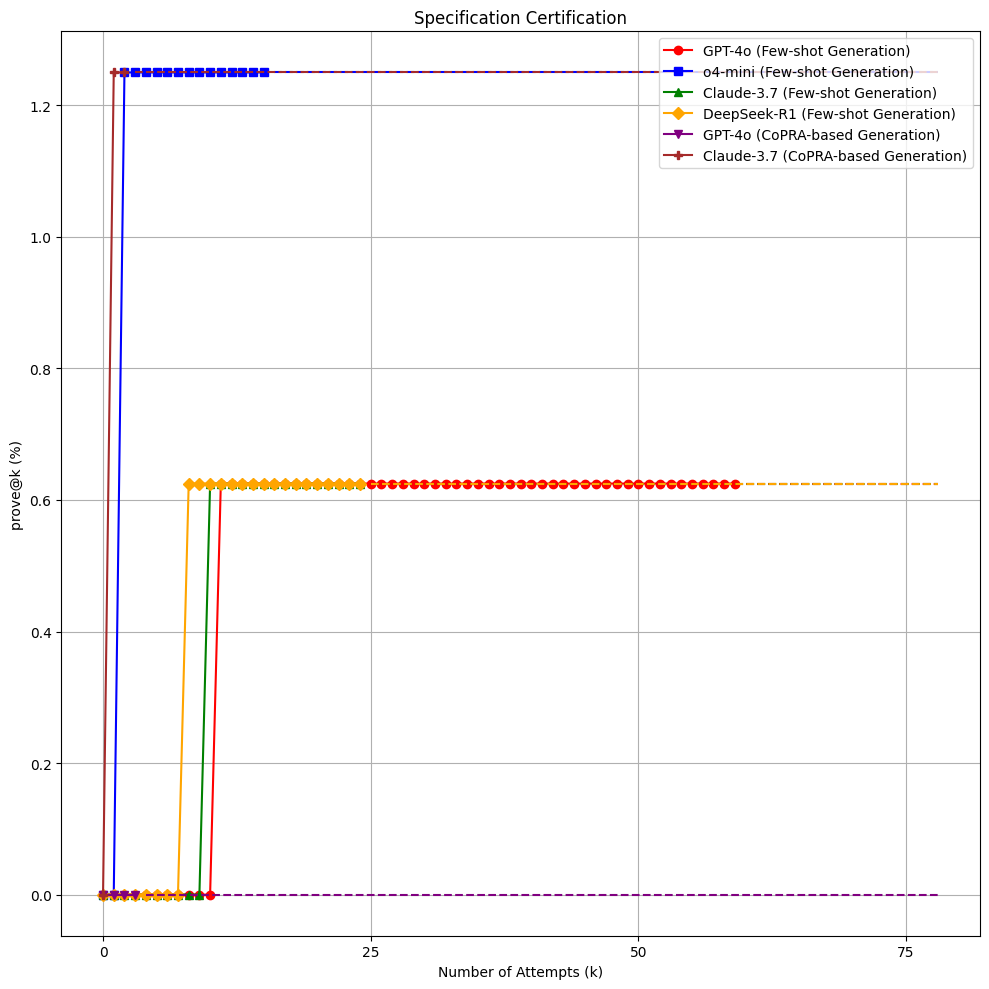

In [72]:
# Go over all model_aggregate_results and plot the proved counts
plt.figure(figsize=(10, 10))
plt.xlabel('Number of Attempts (k)')
plt.ylabel('prove@k (%)')
plt.title('Specification Certification')
relevant_dict = model_aggregate_results[TaskType.SPEC]
i = 0
for proof_mode, model_map in relevant_dict.items():
    proof_mode_name = "CoPRA-based Generation" if proof_mode == ProofMode.COPRA else "Few-shot Generation"
    for model_name, problem_to_attempts in model_map.items():
        proved = relevant_dict[proof_mode][model_name]["proved"]
        plt.plot(range(len(proved)), 
            [v / prob_count * 100 for v in proved], 
            label=f"{get_pretty_model_name(model_name)} ({proof_mode_name})", 
            marker=marker_shapes[i % len(marker_shapes)], 
            color=marker_colors[i % len(marker_colors)])
        if len(proved) < max_tries:
            # extend the line to max_tries with a dashed line
            plt.plot(range(len(proved), max_tries), 
                [proved[-1] / prob_count * 100] * (max_tries - len(proved)), 
                linestyle='--', color=marker_colors[i % len(marker_colors)])
        # Add the % percentage text at the end of each line
        # plt.text(max_tries - 1, proved[-1] / prob_count * 100, f"{proved[-1] / prob_count * 100:.1f}%", 
        #     color=marker_colors[i % len(marker_colors)], fontsize=8, verticalalignment='bottom')
        plt.grid(True)
        i += 1
# Plot the legend on the bottom right
plt.xticks(range(0, max_tries, 25))
# plt.yticks(range(0, 101, 10))
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('aggregated_proved_spec.png')
plt.show()

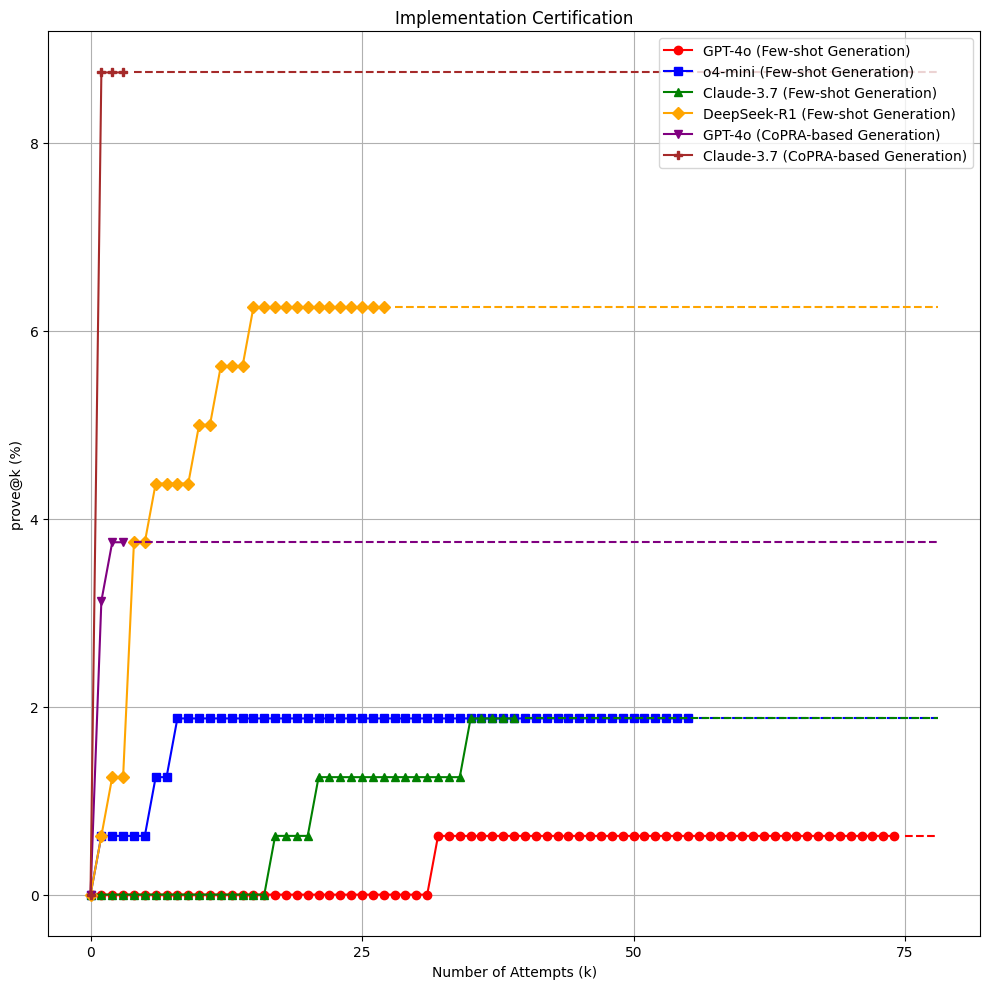

In [73]:
# Go over all model_aggregate_results and plot the proved counts for implementation
plt.figure(figsize=(10, 10))
plt.xlabel('Number of Attempts (k)')
plt.ylabel('prove@k (%)')
plt.title('Implementation Certification')
relevant_dict = model_aggregate_results[TaskType.IMPL]
i = 0
for proof_mode, model_map in relevant_dict.items():
    proof_mode_name = "CoPRA-based Generation" if proof_mode == ProofMode.COPRA else "Few-shot Generation"
    for model_name, problem_to_attempts in model_map.items():
        proved = relevant_dict[proof_mode][model_name]["proved"]
        plt.plot(range(len(proved)), 
            [v / prob_count * 100 for v in proved], 
            label=f"{get_pretty_model_name(model_name)} ({proof_mode_name})", 
            marker=marker_shapes[i % len(marker_shapes)], 
            color=marker_colors[i % len(marker_colors)])
        if len(proved) < max_tries:
            # extend the line to max_tries with a dashed line
            plt.plot(range(len(proved), max_tries), 
                [proved[-1] / prob_count * 100] * (max_tries - len(proved)), 
                linestyle='--', color=marker_colors[i % len(marker_colors)])
        # Add the % percentage text at the end of each line
        # plt.text(max_tries - 1, proved[-1] / prob_count * 100, f"{proved[-1] / prob_count * 100:.1f}%", 
        #     color=marker_colors[i % len(marker_colors)], fontsize=8, verticalalignment='bottom')
        plt.grid(True)
        i += 1
# Plot the legend on the bottom right
plt.xticks(range(0, max_tries, 25))
# plt.yticks(range(0, 101, 10))
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('aggregated_proved_impl.png')
plt.show()